In [5]:
import importlib
import json
from pathlib import Path

# Reload library modules to ensure updated generators are in scope.
import toy_data.generation as gen_module
import toy_data.adapters as adapters_module
importlib.reload(gen_module)
importlib.reload(adapters_module)

from toy_data.generation import (
    generate_nonstationary_coin_flips,
    generate_nonstationary_coin_flips_probabilistic,
)

seed = 42
n = 5001  # 5000 supervised targets + 1

# --- Generate directly from each generator ---
det_sim  = generate_nonstationary_coin_flips(n=n, seed=seed)
prob_sim = generate_nonstationary_coin_flips_probabilistic(
    n=n, seed=seed, noise_std=0.05, min_switch_prob=0.01,
)

det_p  = [s['p_head_before'] for s in det_sim['steps']]
prob_p = [s['p_head_before'] for s in prob_sim['steps']]

print('Deterministic  first 5:', [round(v, 4) for v in det_p[:5]])
print('Probabilistic  first 5:', [round(v, 4) for v in prob_p[:5]])
print('Identical?', det_p == prob_p)

Deterministic  first 5: [0.5279, 0.5756, 0.6179, 0.653, 0.6179]
Probabilistic  first 5: [0.5279, 0.5771, 0.5394, 0.5899, 0.6306]
Identical? False


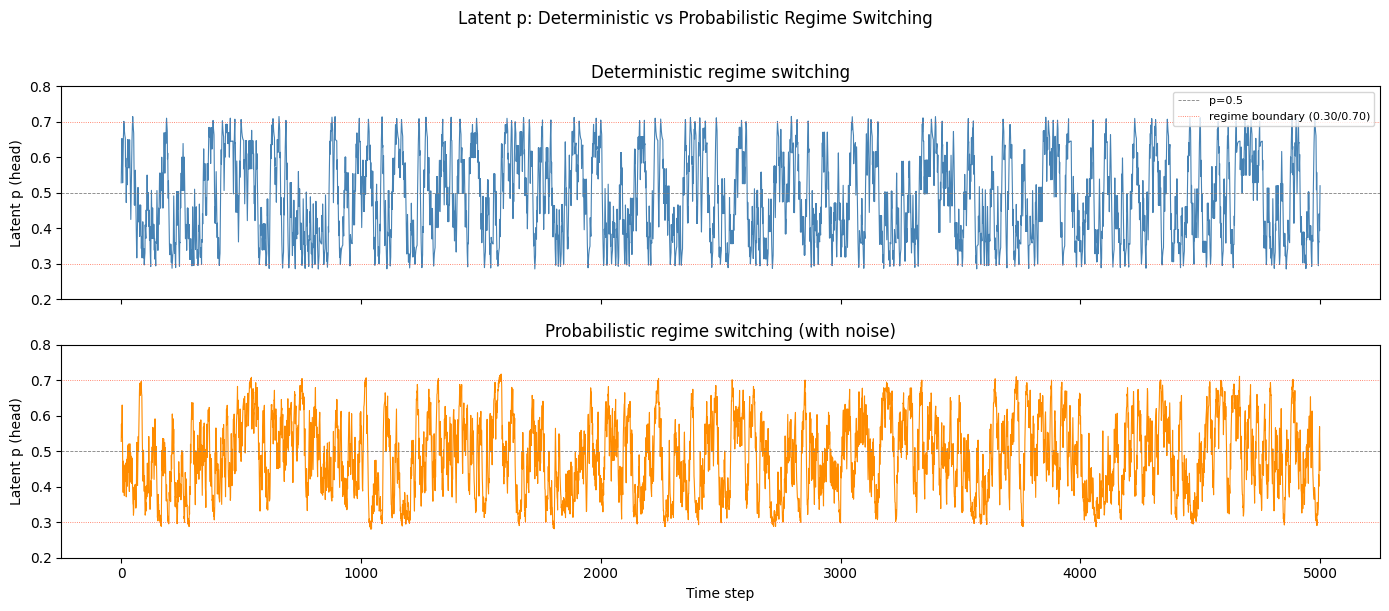

Saved: latent_p_det_vs_prob.png


In [6]:
import matplotlib.pyplot as plt

t = list(range(len(det_p)))

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(t, det_p, linewidth=0.8, color='steelblue')
axes[0].axhline(0.5,  color='grey',  linestyle='--', linewidth=0.6, label='p=0.5')
axes[0].axhline(0.70, color='tomato', linestyle=':',  linewidth=0.6, label='regime boundary (0.30/0.70)')
axes[0].axhline(0.30, color='tomato', linestyle=':',  linewidth=0.6)
axes[0].set_ylabel('Latent p (head)')
axes[0].set_title('Deterministic regime switching')
axes[0].set_ylim(0.2, 0.8)
axes[0].legend(loc='upper right', fontsize=8)

axes[1].plot(t, prob_p, linewidth=0.8, color='darkorange')
axes[1].axhline(0.5,  color='grey',  linestyle='--', linewidth=0.6)
axes[1].axhline(0.70, color='tomato', linestyle=':',  linewidth=0.6)
axes[1].axhline(0.30, color='tomato', linestyle=':',  linewidth=0.6)
axes[1].set_ylabel('Latent p (head)')
axes[1].set_xlabel('Time step')
axes[1].set_title('Probabilistic regime switching (with noise)')
axes[1].set_ylim(0.2, 0.8)

plt.suptitle('Latent p: Deterministic vs Probabilistic Regime Switching', y=1.01)
plt.tight_layout()
plt.savefig('latent_p_det_vs_prob.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: latent_p_det_vs_prob.png')